# EDA of credit card data

Let's start by importing the necessary libraries. For this eda we will import numpy, pandas, matplotlb and seaborn.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now lets work on importing the data from the excel file using pandas. we will store this data in a pandas Data Frame. We will also see 5 random data points of this dataset.

In [65]:
data = pd.read_excel("default of credit card clients.xls", header = 1)
data.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
4353,4354,20000,1,2,2,23,1,2,2,2,...,18391,14235,18955,2500,1000,600,0,5000,1300,1
24636,24637,220000,1,2,1,35,0,0,0,0,...,204740,97722,89971,8000,10098,5828,3000,3000,5000,1
6541,6542,150000,2,3,1,52,-1,-1,-1,-1,...,453,2129,1414,0,1672,453,2129,1414,1961,0
23103,23104,90000,2,3,0,42,0,0,2,0,...,15518,15563,18289,3072,0,1555,600,3000,2000,1
9828,9829,100000,2,2,2,24,1,-1,-1,-2,...,0,0,150,670,0,0,0,150,477,1


As you can see the data columns aren't clear. We will name them properly before doing anything else.

This is much more better. now as Id columns is useless, lets drop it.

In [66]:
data = data.drop(columns = 'ID')
data.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
26794,220000,1,1,2,27,0,0,-1,-1,-1,...,55164,49967,7839,8,2178,55200,50148,10107,0,0
4908,50000,1,2,2,23,-2,-2,-2,-2,-2,...,2277,18488,10263,9910,10294,2284,18546,11294,7752,0
10160,500000,2,1,2,30,-1,-1,-1,-1,-1,...,3377,441,24116,7210,229,3377,441,24116,0,0
23175,290000,2,2,2,41,0,0,0,0,0,...,113459,123967,131735,10000,5620,10000,20000,10000,10000,0
28070,140000,2,1,1,35,0,0,0,0,0,...,79088,73360,67700,4691,4251,4500,3000,2500,2300,0


In [67]:
data.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Now let's understand the meaning of the features. After researching, I found that :
- LIMIT_BAL: Amount of the given credit (in NT dollars).
- SEX: Gender (1 = male; 2 = female).
- EDUCATION: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others; 0, 5, 6 are often grouped into "others/unknown").
- MARRIAGE: Marital status (1 = married; 2 = single; 3 = others).
- AGE: Age in years.
- PAY_0 (or PAY_1), PAY_2, PAY_3, PAY_4, PAY_5, PAY_6: Repayment status for each of the last six months. The values indicate the payment delay:
  - -1 = Pay duly/on time.
  - 0 = No delay.
  - 1 = Payment delay for one month.
  - 2 = Payment delay for two months, etc., up to 9 (nine months and above delay).
- BILL_AMT1 to BILL_AMT6: Amount of bill statement for each of the last six months.
- PAY_AMT1 to PAY_AMT6: Amount of previous payment for each of the last six months.

Now as we know what every feature is, we can explore the data more properly.
Before exploring any feature, lets see if there are any missing values.

In [68]:
data.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There seems to be no missing data!

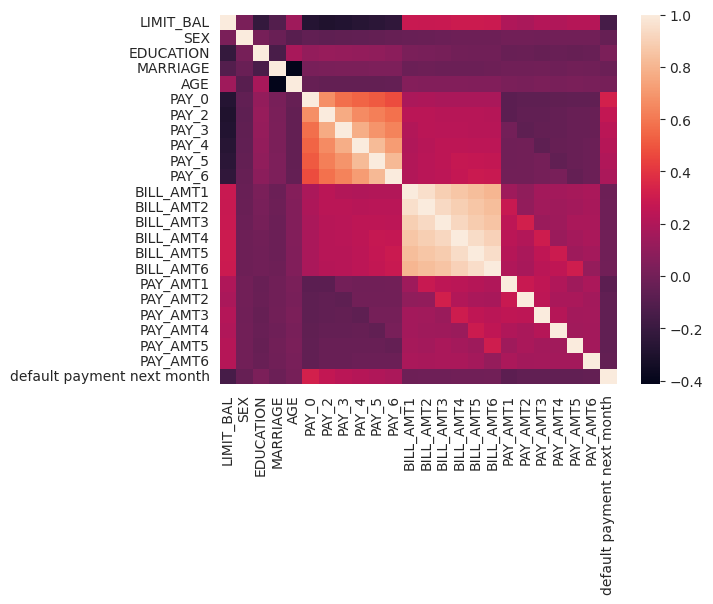

In [69]:
sns.heatmap(data.corr())
plt.show()

In [70]:
print(data.skew(axis = 0))

LIMIT_BAL                      0.992867
SEX                           -0.424183
EDUCATION                      0.970972
MARRIAGE                      -0.018742
AGE                            0.732246
PAY_0                          0.731975
PAY_2                          0.790565
PAY_3                          0.840682
PAY_4                          0.999629
PAY_5                          1.008197
PAY_6                          0.948029
BILL_AMT1                      2.663861
BILL_AMT2                      2.705221
BILL_AMT3                      3.087830
BILL_AMT4                      2.821965
BILL_AMT5                      2.876380
BILL_AMT6                      2.846645
PAY_AMT1                      14.668364
PAY_AMT2                      30.453817
PAY_AMT3                      17.216635
PAY_AMT4                      12.904985
PAY_AMT5                      11.127417
PAY_AMT6                      10.640727
default payment next month     1.343504
dtype: float64


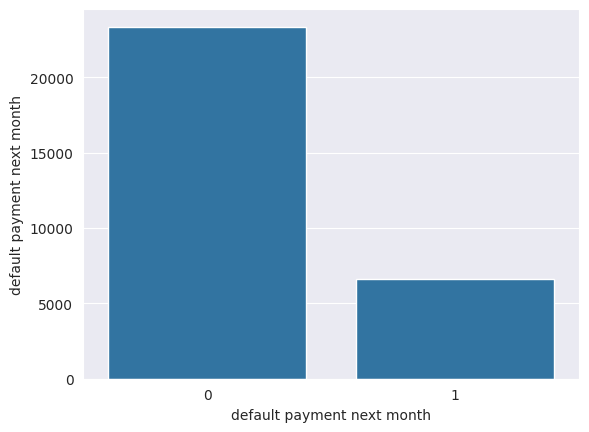

In [71]:
sns.barplot(x = 'default payment next month', y = 'default payment next month',  data = data, estimator = len)
plt.show()

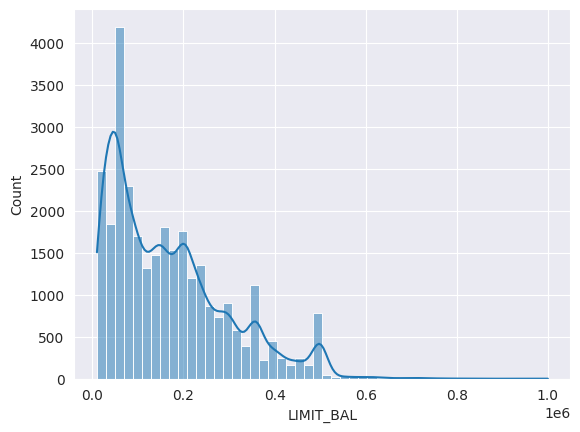

In [72]:
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True, bins = 50)
plt.show()

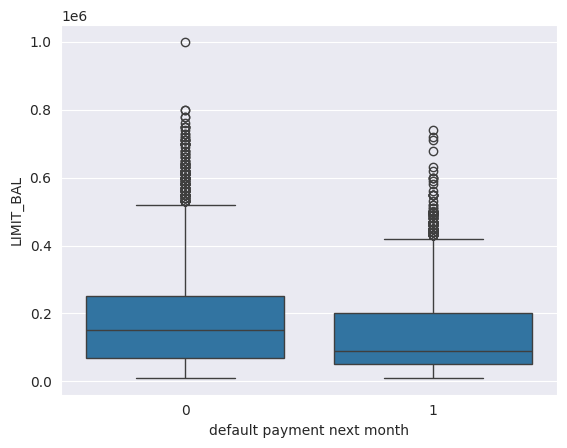

In [73]:
sns.boxplot(y = 'LIMIT_BAL',x = 'default payment next month', data = data)
plt.show()

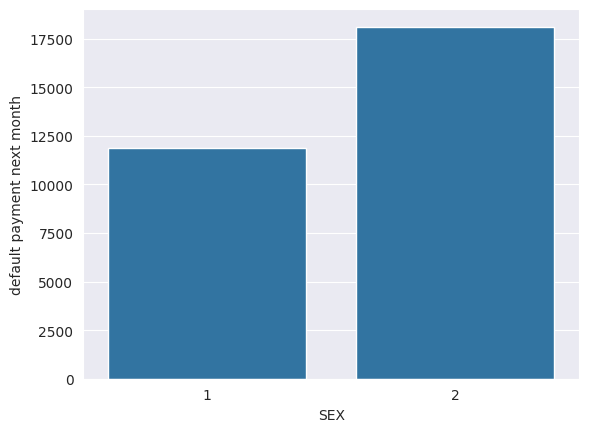

In [74]:
sns.barplot(x = "SEX", y = "default payment next month", data = data, estimator = len)
plt.show()

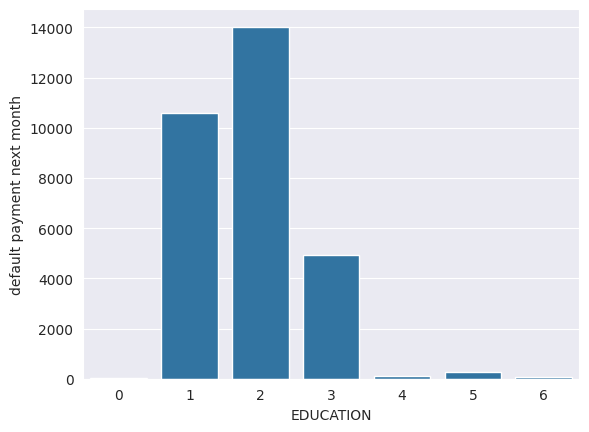

In [75]:
sns.barplot(x = "EDUCATION", y = "default payment next month", data = data, estimator = len)
plt.show()

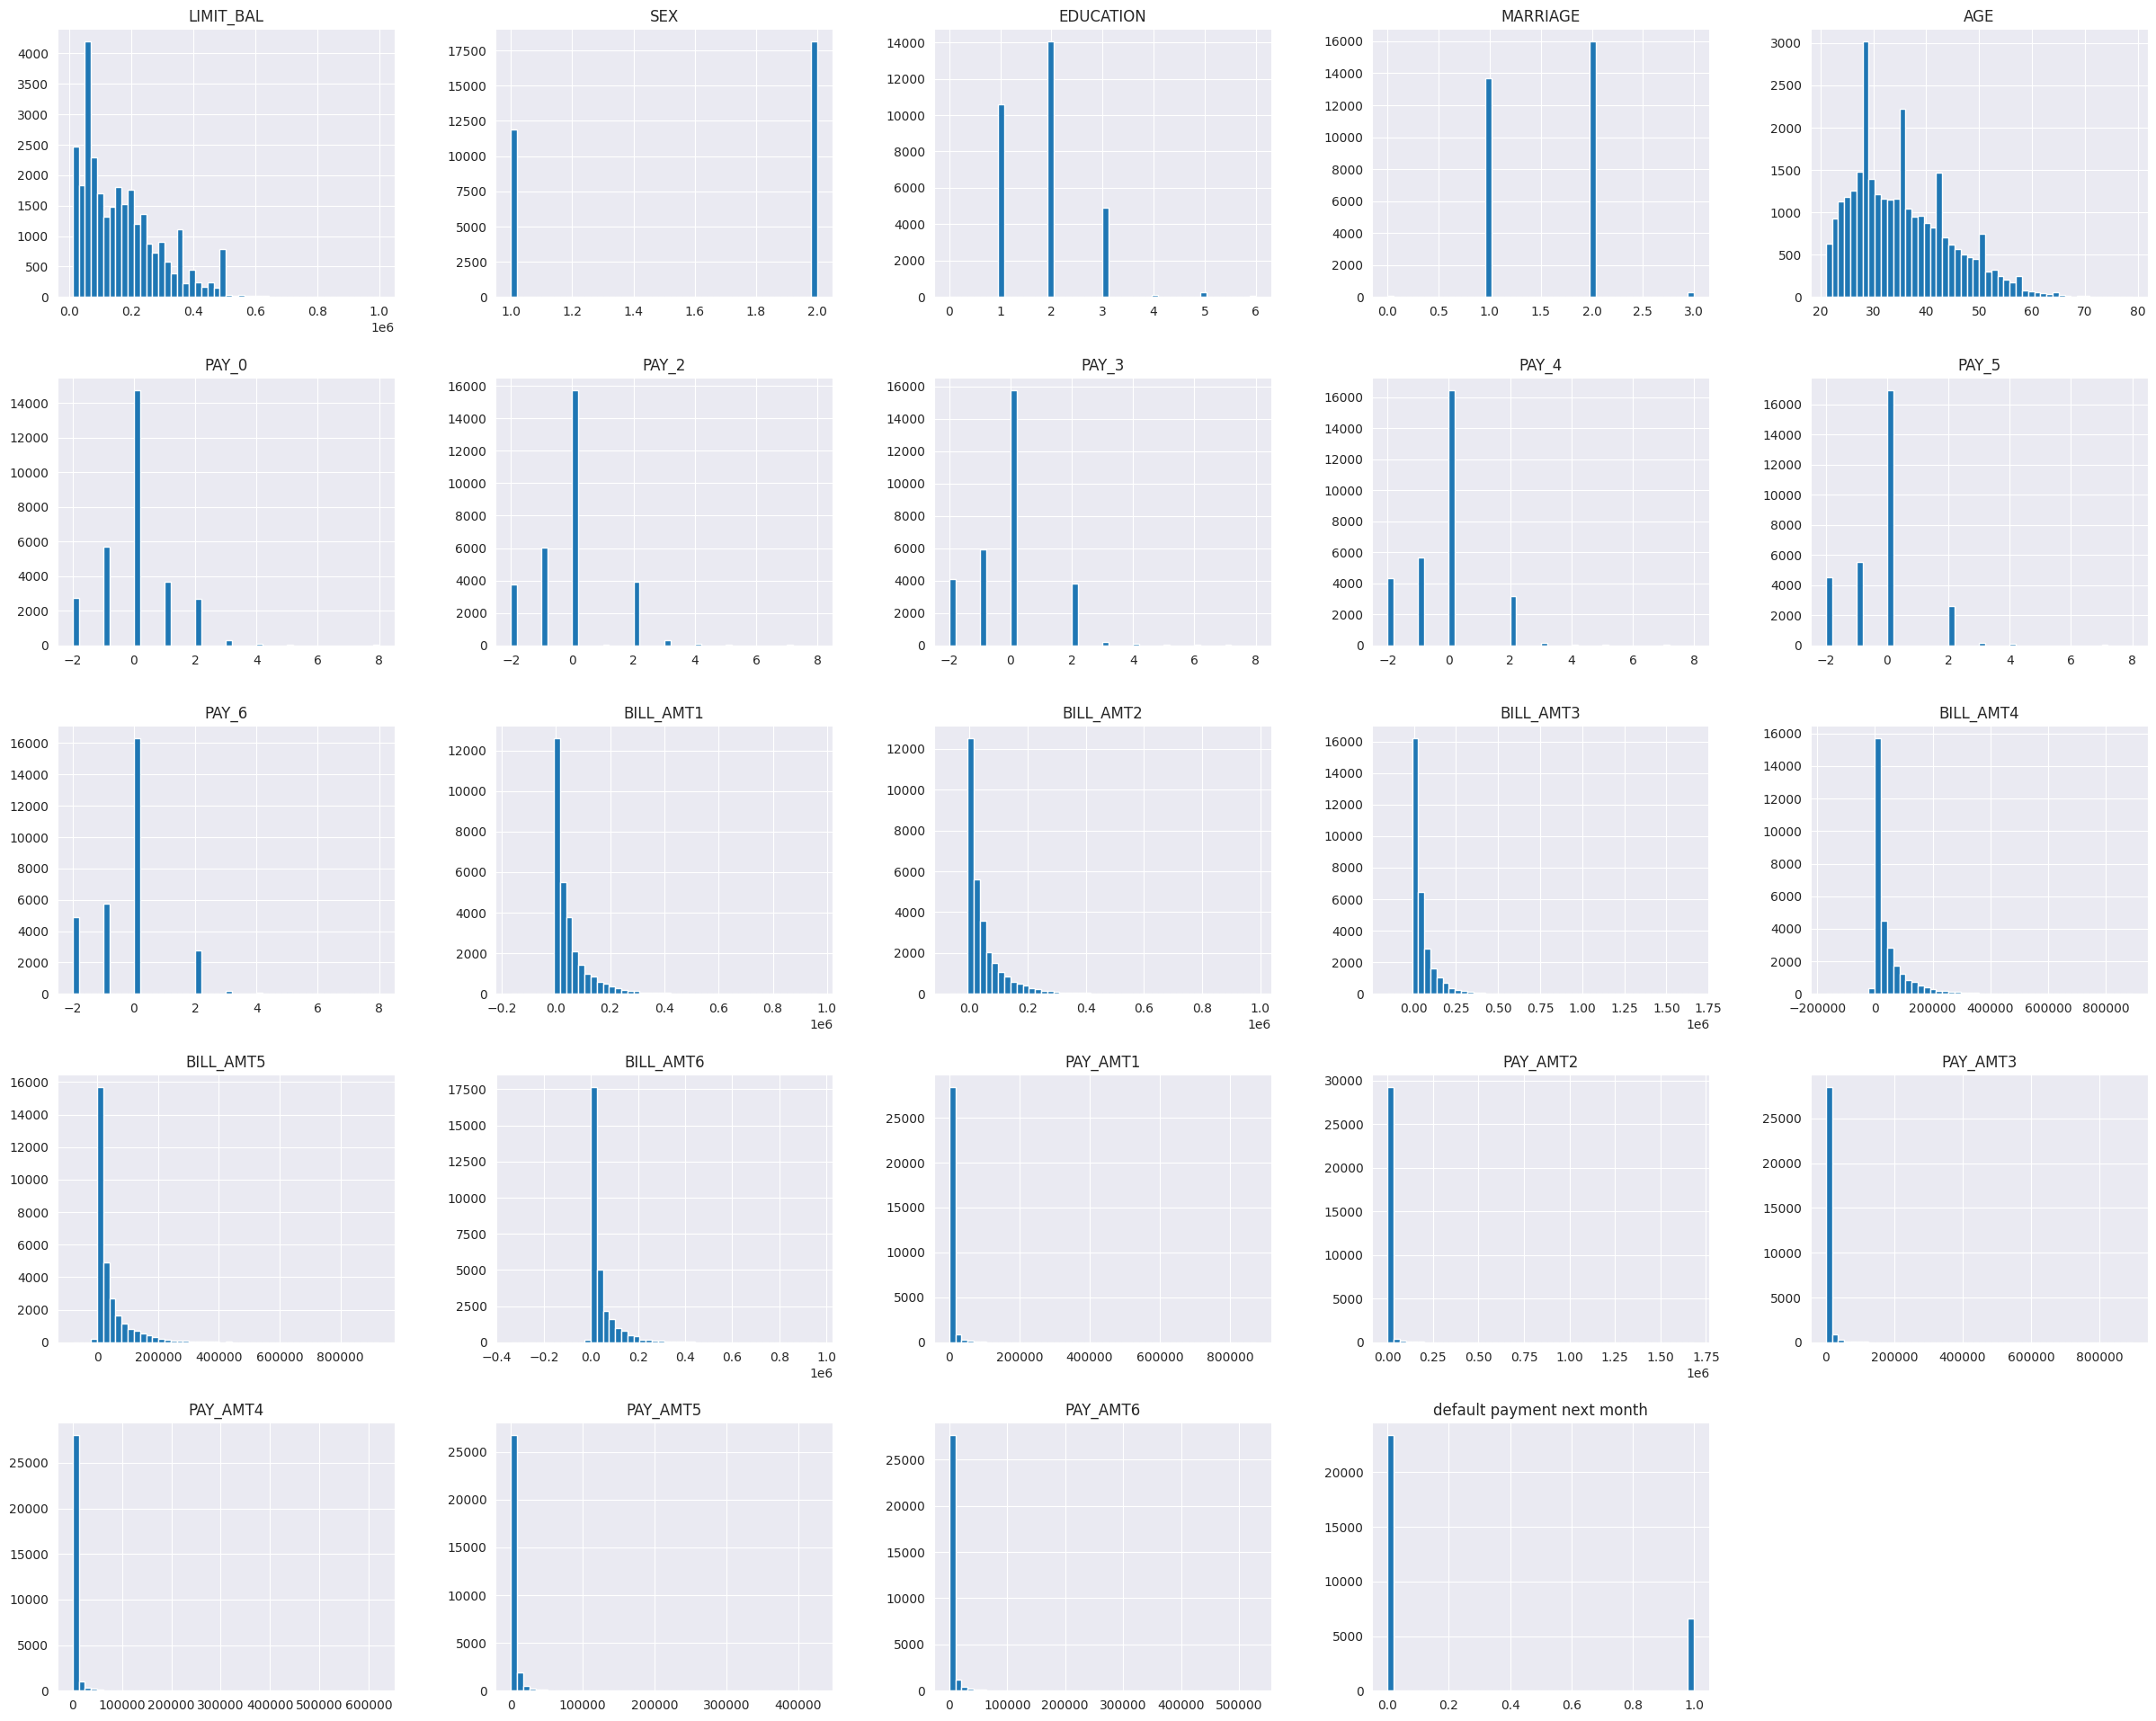

In [76]:
data.hist(figsize=(30, 24), bins=50,layout=(5,5))
plt.show()

In [77]:
data["EDUCATION"].value_counts()/len(data["EDUCATION"])

EDUCATION
2    0.467667
1    0.352833
3    0.163900
5    0.009333
4    0.004100
6    0.001700
0    0.000467
Name: count, dtype: float64

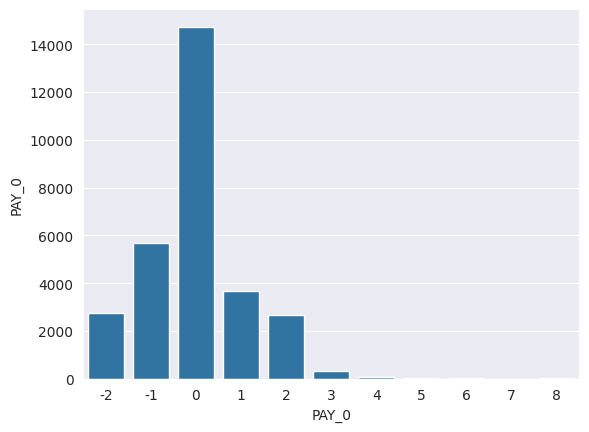

In [78]:
sns.barplot(x = 'PAY_0', y = 'PAY_0',  data = data, estimator = len)
plt.show()

In [79]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import yeojohnson
import numpy as np

to_transform = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6","PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6","LIMIT_BAL","AGE"]

class MinMaxAndYeoJohnson(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lambdas = {}
        self.scalers = {}
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X = X.copy()
        self.feature_names_in_ = X.columns
        for col in to_transform:
            data = np.asarray(X[col], dtype=float)
            transformed, lmbda = yeojohnson(data)
            self.lambdas[col] = lmbda
            scaler = MinMaxScaler()
            #scaler.fit(transformed.reshape(-1, 1))
            self.scalers[col] = scaler
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in to_transform:
            data = np.asarray(X[col], dtype=float)
            x_yeo = yeojohnson(data, lmbda=self.lambdas[col])
            #X[col] = self.scalers[col].transform(x_yeo.reshape(-1, 1)).flatten()
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_, dtype=object)

In [80]:
TOTAL_DATA_POINTS = 30000
TRAIN_RATIO = 0.7
TEST_RATIO = 0.15
VAL_RATIO = 0.15
TRAIN_POINTS = int(TOTAL_DATA_POINTS * TRAIN_RATIO)
VAL_POINTS = int(TOTAL_DATA_POINTS * VAL_RATIO)
TEST_POINTS = int(TOTAL_DATA_POINTS * TEST_RATIO)

In [81]:
train = data[:TRAIN_POINTS]
test = data[TRAIN_POINTS:TRAIN_POINTS+TEST_POINTS]
val = data[TRAIN_POINTS+TEST_POINTS:]

X_train = train.drop(columns="default payment next month")
y_train = train["default payment next month"]

X_test = test.drop(columns="default payment next month")
y_test = test["default payment next month"]

X_val = val.drop(columns="default payment next month")
y_val = val["default payment next month"]

In [82]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

pipeline_logistic = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',LogisticRegression(max_iter=1000))
])

pipeline_catboost = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',CatBoostClassifier())
])

pipeline_xgboost = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',XGBClassifier())
])

In [83]:
pipeline_logistic.fit(X_train, y_train)
y_pred_val_logistic = pipeline_logistic.predict(X_val)

pipeline_catboost.fit(X_train, y_train)
y_pred_val_catboost = pipeline_catboost.predict(X_val)

pipeline_xgboost.fit(X_train, y_train)
y_pred_val_xgboost = pipeline_xgboost.predict(X_val)

/home/aarush-shirpewar/Documents/GitHub/Learning/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Learning rate set to 0.045497
0:	learn: 0.6815897	total: 15.9ms	remaining: 15.9s
1:	learn: 0.6714334	total: 25.5ms	remaining: 12.7s
2:	learn: 0.6621317	total: 34.2ms	remaining: 11.4s
3:	learn: 0.6540677	total: 43.9ms	remaining: 10.9s
4:	learn: 0.6467550	total: 49.6ms	remaining: 9.88s
5:	learn: 0.6395571	total: 56.3ms	remaining: 9.32s
6:	learn: 0.6334979	total: 61.9ms	remaining: 8.78s
7:	learn: 0.6278375	total: 69.6ms	remaining: 8.63s
8:	learn: 0.6225189	total: 75.4ms	remaining: 8.31s
9:	learn: 0.6178611	total: 80.2ms	remaining: 7.94s
10:	learn: 0.6135152	total: 85.6ms	remaining: 7.69s
11:	learn: 0.6096574	total: 90.3ms	remaining: 7.43s
12:	learn: 0.6059310	total: 95.3ms	remaining: 7.24s
13:	learn: 0.6025733	total: 100ms	remaining: 7.04s
14:	learn: 0.5996800	total: 104ms	remaining: 6.86s
15:	learn: 0.5970683	total: 109ms	remaining: 6.69s
16:	learn: 0.5941401	total: 113ms	remaining: 6.54s
17:	learn: 0.5915427	total: 117ms	remaining: 6.4s
18:	learn: 0.5891760	total: 122ms	remaining: 6.28s

In [84]:

from sklearn.model_selection import StratifiedKFold, cross_validate

pipelines = [pipeline_logistic, pipeline_catboost, pipeline_xgboost]
names = ["Pipeline 1", "Pipeline 2", "Pipeline 3"]

# Use StratifiedKFold for classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

for name, pipe in zip(names, pipelines):
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {results['test_accuracy'].mean():.4f}")
    print(f"Precision: {results['test_precision'].mean():.4f}")
    print(f"Recall:    {results['test_recall'].mean():.4f}")
    print(f"F1-score:  {results['test_f1'].mean():.4f}")

/home/aarush-shirpewar/Documents/GitHub/Learning/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/aarush-shirpewar/Documents/GitHub/Learning/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as sho


=== Pipeline 1 ===
Accuracy:  0.6668
Precision: 0.6162
Recall:    0.6567
F1-score:  0.6123
Learning rate set to 0.041363
0:	learn: 0.6825339	total: 9.12ms	remaining: 9.11s
1:	learn: 0.6730402	total: 18.5ms	remaining: 9.23s
2:	learn: 0.6643187	total: 23ms	remaining: 7.65s
3:	learn: 0.6566707	total: 28.9ms	remaining: 7.2s
4:	learn: 0.6496496	total: 34.1ms	remaining: 6.79s
5:	learn: 0.6431005	total: 39.4ms	remaining: 6.53s
6:	learn: 0.6373814	total: 44.8ms	remaining: 6.36s
7:	learn: 0.6317718	total: 51.1ms	remaining: 6.34s
8:	learn: 0.6264747	total: 56.7ms	remaining: 6.24s
9:	learn: 0.6220204	total: 63.7ms	remaining: 6.3s
10:	learn: 0.6175504	total: 67.9ms	remaining: 6.1s
11:	learn: 0.6134096	total: 73.7ms	remaining: 6.07s
12:	learn: 0.6100495	total: 80.6ms	remaining: 6.12s
13:	learn: 0.6066167	total: 87.6ms	remaining: 6.17s
14:	learn: 0.6031775	total: 92.8ms	remaining: 6.09s
15:	learn: 0.6005167	total: 97.7ms	remaining: 6s
16:	learn: 0.5975604	total: 103ms	remaining: 5.94s
17:	learn: 0.

In [85]:
from sklearn.metrics import recall_score, f1_score, accuracy_score, precision_score

recall_total = recall_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])
f1_total = f1_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])
accuracy_total = accuracy_score(y_val, y_pred_val_catboost)
precision_total = precision_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])

print("CatBoost:")
print("Overall recall:", recall_total)
print("Overall F1-score:", f1_total)
print("Overall accuracy:", accuracy_total)
print("Overall precision:", precision_total)


CatBoost:
Overall recall: [0.84593679 0.58682008]
Overall F1-score: [0.86435058 0.54386815]
Overall accuracy: 0.7908888888888889
Overall precision: [0.88358385 0.50677507]


In [86]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier

pipeline_decision_tree = pipeline_logistic = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',DecisionTreeClassifier(max_depth=1))
])

pipeline_decision_tree.fit(X_train, y_train)
y_pred_val_decision_tree = pipeline_decision_tree.predict(X_val)

recall_total = recall_score(y_val, y_pred_val_decision_tree,  )
f1_total = f1_score(y_val, y_pred_val_decision_tree,  )
accuracy_total = accuracy_score(y_val, y_pred_val_decision_tree)
precision_total = precision_score(y_val, y_pred_val_decision_tree, )

print("Stump:")
print("Overall recall:", recall_total)
print("Overall F1-score:", f1_total)
print("Overall accuracy:", accuracy_total)
print("Overall precision:", precision_total)

Stump:
Overall recall: 0.5104602510460251
Overall F1-score: 0.5072765072765073
Overall accuracy: 0.7893333333333333
Overall precision: 0.5041322314049587


In [87]:
dt = pipeline_decision_tree.named_steps['model']
pre = pipeline_decision_tree.named_steps['yeo_johnson_and_min_max']

# Get feature names after preprocessing
feature_names = pre.get_feature_names_out()
from sklearn.tree import export_text

dt = pipeline_decision_tree.named_steps['model']
tree_rules = export_text(dt, feature_names=feature_names)

print(tree_rules)

|--- PAY_0 <= 0.50
|   |--- class: 0
|--- PAY_0 >  0.50
|   |--- class: 1



In [88]:

model = Pipeline([
('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
('ROS',RandomOverSampler(sampling_strategy='minority')),
('model',CatBoostClassifier(max_depth = 3,iterations = 2000,learning_rate=0.011281342875793118,l2_leaf_reg=0.011427065560469116,border_count=105,loss_function='Logloss',random_seed = 42,verbose=False))
])
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("accuracy:", accuracy_score(y_test, preds))
print("recall:", recall_score(y_test, preds))
print("precision:", precision_score(y_test, preds))
print("f1-score:", f1_score(y_test, preds))



accuracy: 0.7868888888888889
recall: 0.583710407239819
precision: 0.46612466124661245
f1-score: 0.5183324962330487
